In [12]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('../data/diabetes_prediction_dataset.csv')

In [14]:
df.shape

(100000, 9)

In [15]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [16]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [18]:
df.duplicated().sum()

np.int64(3854)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.shape

(96146, 9)

In [22]:
df.sample(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
28646,Male,32.0,0,0,never,20.90,4.0,126,0
39363,Male,43.0,0,0,not current,27.76,6.1,240,1
75578,Female,62.0,0,0,ever,37.52,8.8,300,1
40024,Male,9.0,0,0,No Info,17.61,5.7,126,0
96662,Female,31.0,0,0,never,35.80,6.6,80,0


In [23]:
df['hypertension'].unique()

array([0, 1])

In [24]:
df['heart_disease'].unique()

array([1, 0])

In [25]:
df['diabetes'].unique()

array([0, 1])

In [26]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

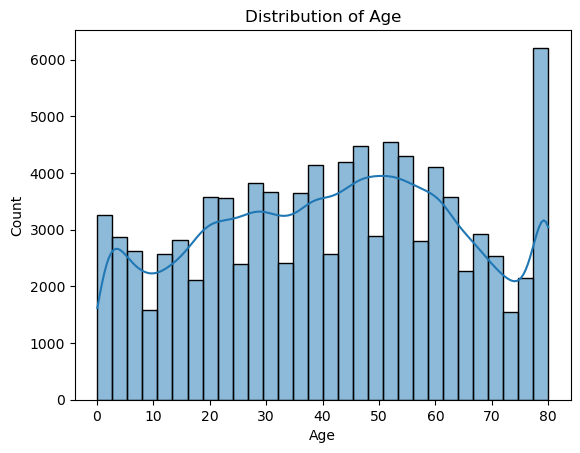

In [27]:
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

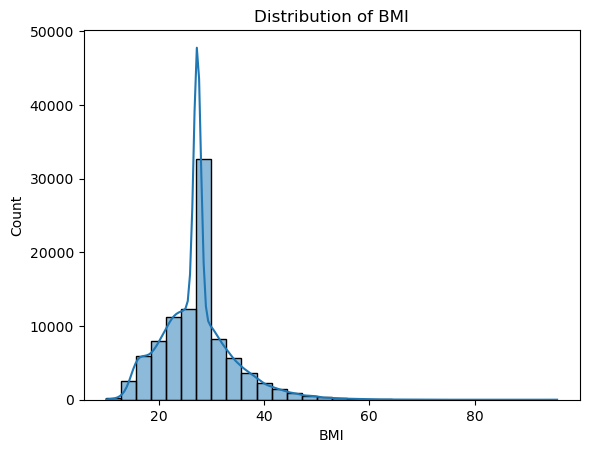

In [31]:
sns.histplot(df['bmi'], kde=True, bins=30)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

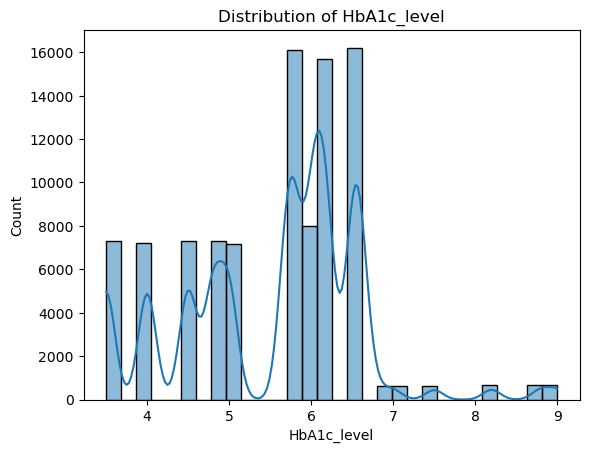

In [32]:
sns.histplot(df['HbA1c_level'], kde=True, bins=30)
plt.title('Distribution of HbA1c_level')
plt.xlabel('HbA1c_level')
plt.ylabel('Count')
plt.show()

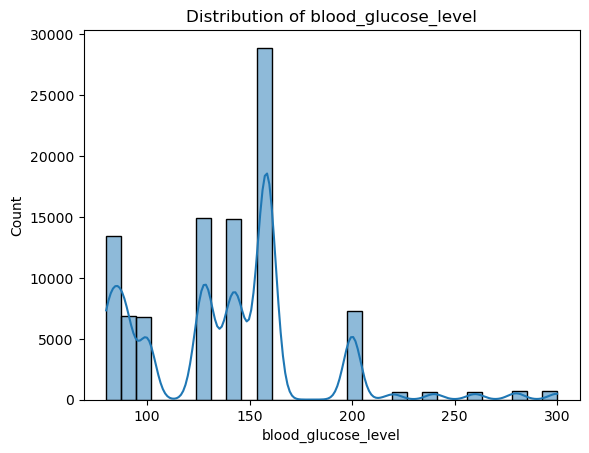

In [33]:
sns.histplot(df['blood_glucose_level'], kde=True, bins=30)
plt.title('Distribution of blood_glucose_level')
plt.xlabel('blood_glucose_level')
plt.ylabel('Count')
plt.show()

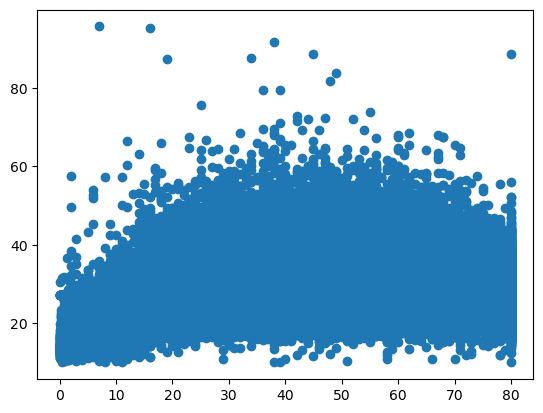

In [34]:
plt.scatter(x=df['age'],y=df['bmi'])

In [42]:
df['age'].value_counts().sort_index().tail(10)

age
71.0     857
72.0     780
73.0     810
74.0     746
75.0     712
76.0     724
77.0     719
78.0     670
79.0     607
80.0    4932
Name: count, dtype: int64

In [45]:
for col in ['bmi', 'HbA1c_level', 'blood_glucose_level']:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

bmi: 5354 outliers
HbA1c_level: 1312 outliers
blood_glucose_level: 2031 outliers


In [46]:
for col in ['bmi', 'HbA1c_level', 'blood_glucose_level']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower) | (df[col] > upper)
    diabetes_rate_outliers = df[outlier_mask]['diabetes'].mean()
    diabetes_rate_normal = df[~outlier_mask]['diabetes'].mean()

    print(f"{col}: diabetes rate in outliers = {diabetes_rate_outliers:.2%}, "
          f"in normal range = {diabetes_rate_normal:.2%}")

bmi: diabetes rate in outliers = 23.66%, in normal range = 7.95%
HbA1c_level: diabetes rate in outliers = 100.00%, in normal range = 7.56%
blood_glucose_level: diabetes rate in outliers = 100.00%, in normal range = 6.85%


In [48]:
df.sample(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
71660,Female,55.0,0,0,never,24.80,5.7,159,0
32750,Female,14.0,0,0,No Info,19.96,5.0,140,0
89432,Male,20.0,0,0,current,27.12,3.5,140,0
75297,Male,40.0,0,0,never,25.62,6.0,126,0
71628,Female,23.0,0,0,current,36.93,4.5,90,0


In [49]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(76916, 8) (19230, 8)
diabetes
0    0.911774
1    0.088226
Name: proportion, dtype: float64
diabetes
0    0.911804
1    0.088196
Name: proportion, dtype: float64


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler

ohe_cols = ['gender', 'smoking_history']
minmax_cols = ['age']
robust_cols = ['bmi', 'HbA1c_level', 'blood_glucose_level']
passthrough_cols = ['hypertension', 'heart_disease']

preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
    ('minmax', MinMaxScaler(), minmax_cols),
    ('robust', RobustScaler(), robust_cols),
    ('passthrough', 'passthrough', passthrough_cols)
])

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_full = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])
pipe_full.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('minmax', MinMaxScaler(),
                                                  ['age']),
                                                 ('robust', RobustScaler(),
                                                  ['bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('passthrough', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [53]:
drop_cols = ['HbA1c_level', 'blood_glucose_level']
X_train_reduced = X_train.drop(columns=drop_cols)
X_test_reduced = X_test.drop(columns=drop_cols)

preprocessor_reduced = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
    ('minmax', MinMaxScaler(), minmax_cols),
    ('robust', RobustScaler(), ['bmi']),
    ('passthrough', 'passthrough', passthrough_cols)
])

In [54]:
pipe_reduced = Pipeline([
    ('preprocessor', preprocessor_reduced),
    ('model', LogisticRegression(max_iter=1000))
])
pipe_reduced.fit(X_train_reduced, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('minmax', MinMaxScaler(),
                                                  ['age']),
                                                 ('robust', RobustScaler(),
                                                  ['bmi']),
                                                 ('passthrough', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [55]:
from sklearn.metrics import roc_auc_score

y_proba_full = pipe_full.predict_proba(X_test)[:, 1]
y_proba_reduced = pipe_reduced.predict_proba(X_test_reduced)[:, 1]

auc_full = roc_auc_score(y_test, y_proba_full)
auc_reduced = roc_auc_score(y_test, y_proba_reduced)

print(f"Full model AUC: {auc_full:.4f}")
print(f"Reduced model AUC: {auc_reduced:.4f}")

Full model AUC: 0.9599
Reduced model AUC: 0.8248


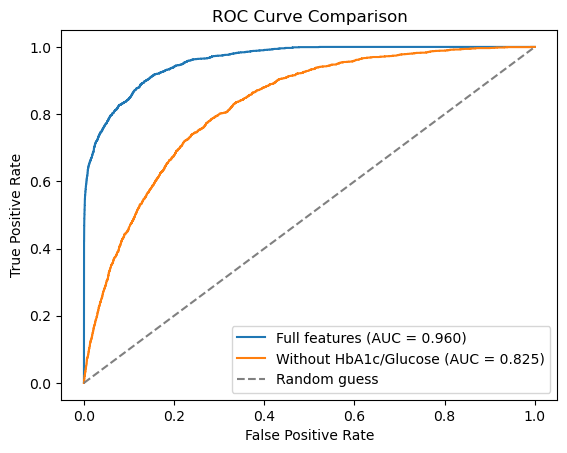

In [56]:
from sklearn.metrics import roc_curve

fpr_full, tpr_full, _ = roc_curve(y_test, y_proba_full)
fpr_reduced, tpr_reduced, _ = roc_curve(y_test, y_proba_reduced)

plt.plot(fpr_full, tpr_full, label=f'Full features (AUC = {auc_full:.3f})')
plt.plot(fpr_reduced, tpr_reduced, label=f'Without HbA1c/Glucose (AUC = {auc_reduced:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

model_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)

model_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)

model_en = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1.0, max_iter=1000)

In [58]:
from sklearn.metrics import accuracy_score

models = {
    'Ridge (L2)': LogisticRegression(penalty='l2', C=1.0, max_iter=1000),
    'Lasso (L1)': LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000),
    'ElasticNet': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1.0, max_iter=1000)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {'auc': auc, 'acc': acc, 'proba': y_proba}
    print(f"{name}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

Ridge (L2): Accuracy = 0.9596, AUC = 0.9599
Lasso (L1): Accuracy = 0.9596, AUC = 0.9599
ElasticNet: Accuracy = 0.9596, AUC = 0.9599


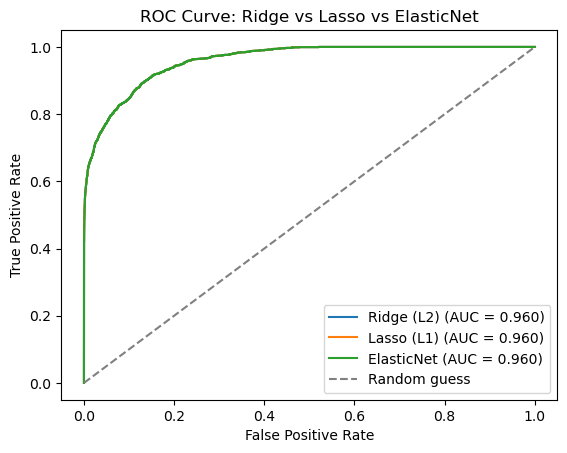

In [59]:
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Ridge vs Lasso vs ElasticNet')
plt.legend()
plt.show()